In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Load
df = pd.read_csv("tea_train.csv")

# 2) Parse date + sort
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# 3) Rename columns to easier names (keeps your original data intact)
df = df.rename(columns={
    "Rain fall": "rainfall",
    "Air Tempurature": "air_temp",
    "Tea Type": "tea_type",
    "Tea Production": "tea_prod"
})

# 4) Ensure month number exists (if not, create from date)
if "month_num" not in df.columns:
    df["month_num"] = df["date"].dt.month

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

df.head()


,Year,Month,Elevation,rainfall,Humidity,air_temp,tea_type,tea_prod,month_num,date
0,2013,JAN,HIGH,291.10,85.25,19.32,BIO TEA,84682.5,1,2013-01-01
1,2013,JAN,MEDIUM,257.05,83.50,21.60,TOTAL BLACK TEA,3335171.0,1,2013-01-01
2,2013,JAN,MEDIUM,257.05,83.50,21.60,RECLAIMED TEA,7327.0,1,2013-01-01
3,2013,JAN,MEDIUM,257.05,83.50,21.60,ORTHODOX TEA,2530143.0,1,2013-01-01
4,2013,JAN,MEDIUM,257.05,83.50,21.60,INSTANT TEA,0.0,1,2013-01-01


Objective 1: Temporal Patterns (When)
1A) Seasonality: average production by month (across all years)

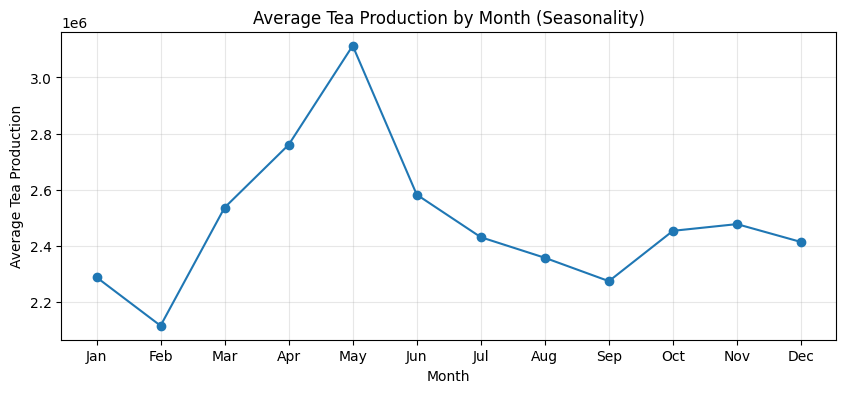

In [ ]:
monthly = (df.groupby("month_num")["tea_prod"]
             .mean()
             .reindex(range(1,13)))

plt.figure(figsize=(10,4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.xticks(range(1,13), month_names)
plt.title("Average Tea Production by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Tea Production")
plt.grid(True, alpha=0.3)
plt.show()


How to read it

Peaks = “high season” months for production.

Dips = “low season” months.

Big peak-to-dip range ⇒ strong seasonality.


1B) Long-term trend: monthly total production over time + rolling mean

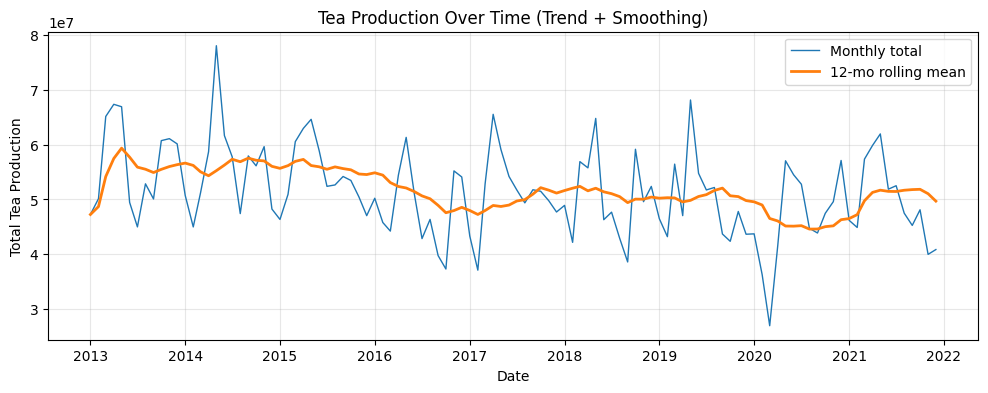

In [ ]:
# Total production per month (across tea types/elevations)
ts = df.groupby("date")["tea_prod"].sum().sort_index()

roll12 = ts.rolling(12, min_periods=1).mean()

plt.figure(figsize=(12,4))
plt.plot(ts.index, ts.values, linewidth=1, label="Monthly total")
plt.plot(roll12.index, roll12.values, linewidth=2, label="12-mo rolling mean")
plt.title("Tea Production Over Time (Trend + Smoothing)")
plt.xlabel("Date")
plt.ylabel("Total Tea Production")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


How to read it

The thin line shows month-to-month variation.

The rolling mean shows long-term trend (growth/decline) without seasonal noise.


1C) Year × Month heatmap (seasonality strength varies by year)

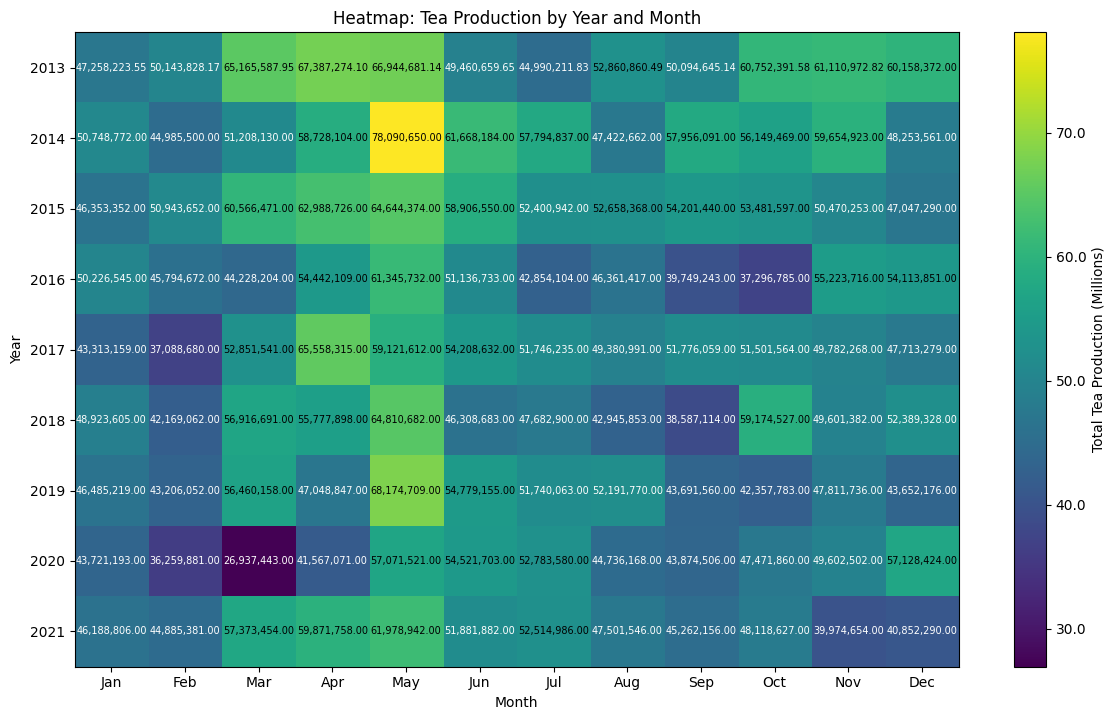

In [ ]:
import matplotlib.ticker as ticker

year_month = (df.groupby(["Year","month_num"])["tea_prod"]
                .sum()
                .reset_index())

pivot = year_month.pivot(index="Year", columns="month_num", values="tea_prod").sort_index()
pivot = pivot.reindex(columns=range(1,13))

plt.figure(figsize=(12, len(pivot.index) * 0.7 + 1)) # Adjust figure height based on number of years
im = plt.imshow(pivot.values, aspect="auto", cmap="viridis") # Store the image object

# Custom formatter function to display values in millions
def millions_formatter(x, pos):
    return f'{x / 1_000_000:.1f}' # Format to 1 decimal place for colorbar ticks

# Create a formatter
formatter = ticker.FuncFormatter(millions_formatter)

plt.colorbar(im, label="Total Tea Production (Millions)", format=formatter)
plt.xticks(np.arange(12), month_names)
plt.yticks(np.arange(len(pivot.index)), pivot.index)
plt.title("Heatmap: Tea Production by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")

# Add text annotations
# Determine min/max values for normalization to help with text color selection
min_val = pivot.values.min()
max_val = pivot.values.max()
val_range = max_val - min_val

for i in range(pivot.shape[0]): # rows (years)
    for j in range(pivot.shape[1]): # columns (months)
        value = pivot.iloc[i, j]
        if pd.notna(value): # Only add text for non-NaN values
            # Format to 2 decimal places (raw value, not in millions)
            text_val = f"{value:,.2f}"

            # Heuristic for text color based on value relative to the range and colormap (viridis)
            # Viridis goes from dark blue/purple (low) to bright yellow (high).
            # Use white text on dark cells, black text on bright cells.
            if val_range > 0:
                normalized_value = (value - min_val) / val_range
            else:
                normalized_value = 0.5 # Default to middle if all values are the same

            color = "white" if normalized_value < 0.5 else "black" # Adjust threshold as needed

            plt.text(j, i, text_val,
                     ha="center", va="center", color=color, fontsize=7) # Smaller font for readability

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

How to read it

Brighter cells = higher production.

If the same months are always bright each year ⇒ stable seasonal pattern.

If brightness shifts across years ⇒ seasonality is changing over time.

Objective 2: Climatic Influence (Why)
2A) Scatter + trend lines (Rainfall, Humidity, Temperature vs production)

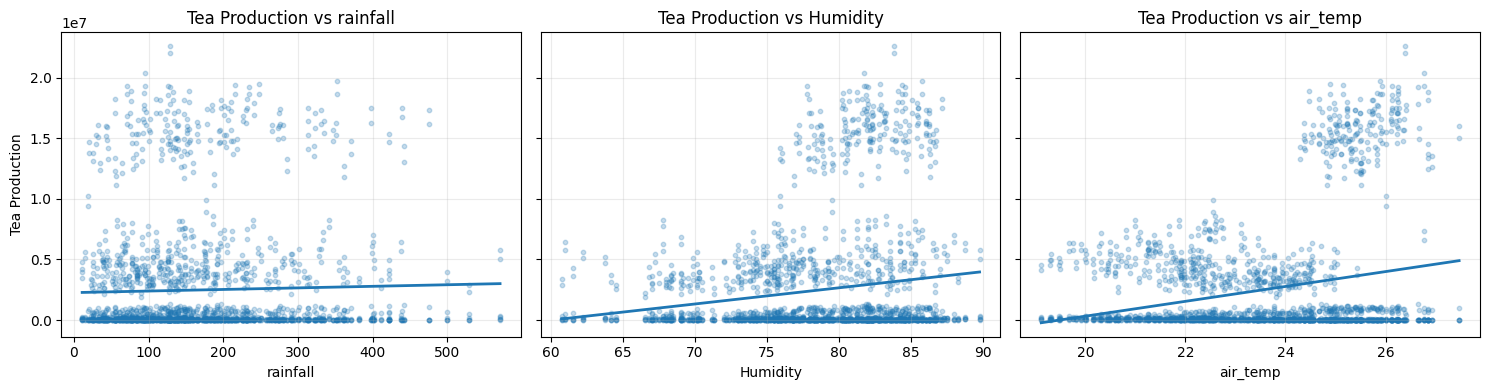

In [ ]:
climate_vars = ["rainfall", "Humidity", "air_temp"]

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)
for ax, col in zip(axes, climate_vars):
    x = df[col].values
    y = df["tea_prod"].values

    ax.scatter(x, y, s=10, alpha=0.25)

    # simple linear trend line
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m*xs + b, linewidth=2)

    ax.set_title(f"Tea Production vs {col}")
    ax.set_xlabel(col)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Tea Production")
plt.tight_layout()
plt.show()


How to read it

Upward trend line ⇒ production tends to increase as the climate variable increases.

Downward trend line ⇒ negative relationship.

Wide vertical spread ⇒ climate alone doesn’t explain everything (tea type/elevation/time matter too).

2B) Correlation heatmap (quick “direction + strength” check)

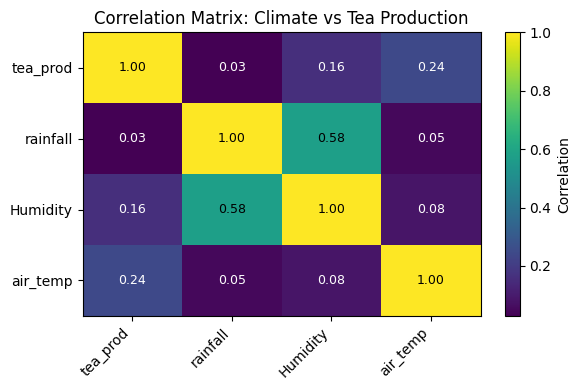

tea_prod    1.000000
air_temp    0.241590
Humidity    0.160478
rainfall    0.029004
Name: tea_prod, dtype: float64


In [ ]:
corr = df[["tea_prod","rainfall","Humidity","air_temp"]].corr(numeric_only=True)

plt.figure(figsize=(6,4))
im = plt.imshow(corr.values, aspect="auto", cmap="viridis") # Store the image object
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix: Climate vs Tea Production")

# Add text annotations
min_val = corr.values.min()
max_val = corr.values.max()
val_range = max_val - min_val

for i in range(corr.shape[0]): # rows
    for j in range(corr.shape[1]): # columns
        value = corr.iloc[i, j]
        if pd.notna(value): # Only add text for non-NaN values
            text_val = f"{value:.2f}" # Format to 2 decimal places

            # Heuristic for text color based on value relative to the range and colormap (viridis)
            # Viridis goes from dark blue/purple (low) to bright yellow (high).
            # Use white text on dark cells, black text on bright cells.
            if val_range > 0:
                normalized_value = (value - min_val) / val_range
            else:
                normalized_value = 0.5 # Default to middle if all values are the same

            color = "white" if normalized_value < 0.5 else "black" # Adjust threshold as needed

            plt.text(j, i, text_val,
                     ha="center", va="center", color=color, fontsize=9)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print(corr["tea_prod"].sort_values(ascending=False))

How to read it

Correlation near +1: strong positive association.

Near -1: strong negative association.

Near 0: weak linear association (could still be nonlinear).

2C) Nonlinear “binned effect” plots (often more realistic than correlation)

/tmp/ipython-input-2813863998.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("bin")[y_col].agg(["mean","count"]).reset_index()


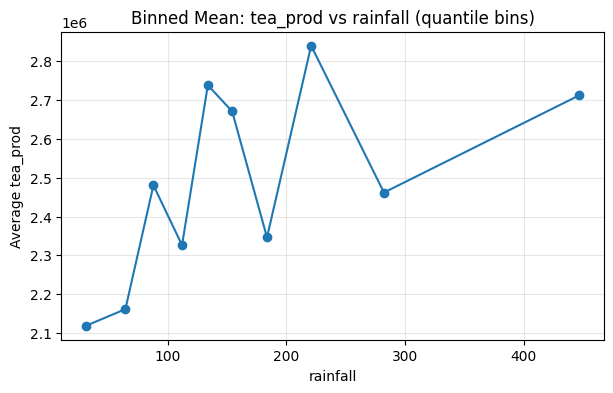

/tmp/ipython-input-2813863998.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("bin")[y_col].agg(["mean","count"]).reset_index()


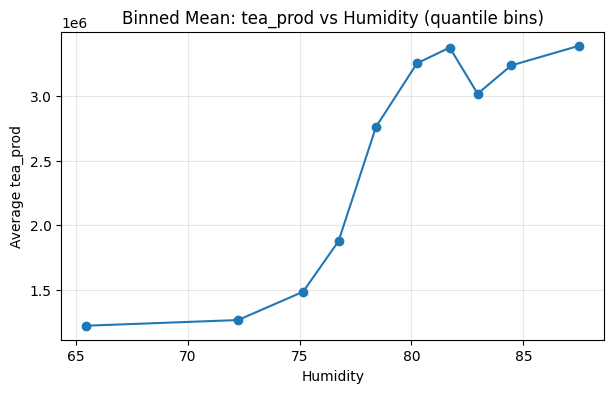

/tmp/ipython-input-2813863998.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("bin")[y_col].agg(["mean","count"]).reset_index()


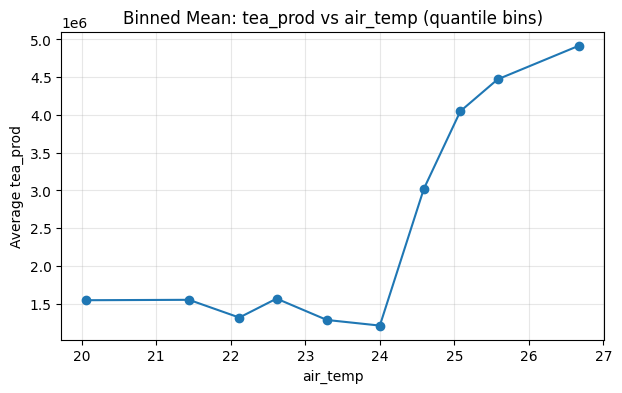

In [ ]:
def binned_mean_plot(x_col, y_col="tea_prod", bins=10):
    tmp = df[[x_col, y_col]].copy()
    tmp["bin"] = pd.qcut(tmp[x_col], q=bins, duplicates="drop")
    g = tmp.groupby("bin")[y_col].agg(["mean","count"]).reset_index()
    centers = g["bin"].apply(lambda i: i.mid).astype(float)

    plt.figure(figsize=(7,4))
    plt.plot(centers, g["mean"], marker="o")
    plt.title(f"Binned Mean: {y_col} vs {x_col} (quantile bins)")
    plt.xlabel(x_col)
    plt.ylabel(f"Average {y_col}")
    plt.grid(True, alpha=0.3)
    plt.show()

for v in ["rainfall","Humidity","air_temp"]:
    binned_mean_plot(v, bins=10)


/tmp/ipython-input-200363615.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x="bin_range", y=y_col, showfliers=False, palette="viridis")


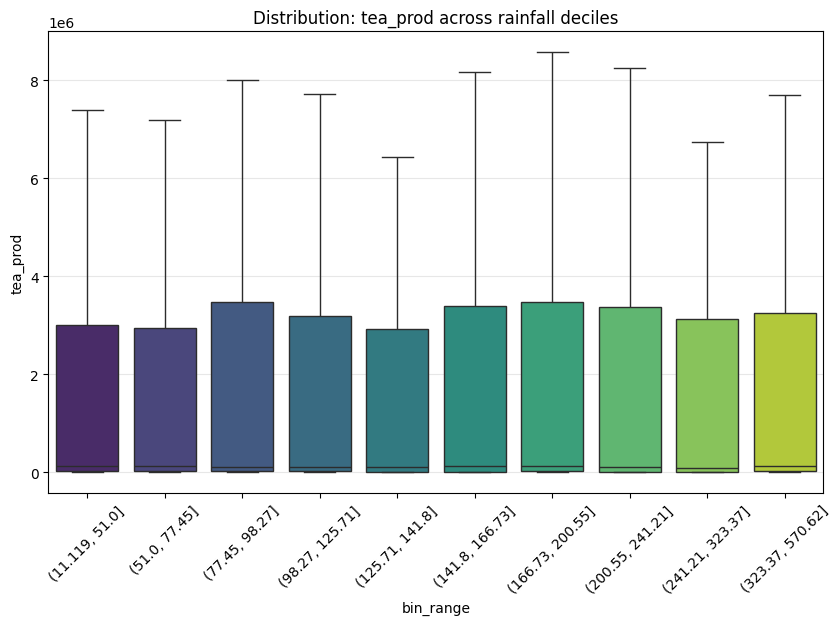

/tmp/ipython-input-200363615.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x="bin_range", y=y_col, showfliers=False, palette="viridis")


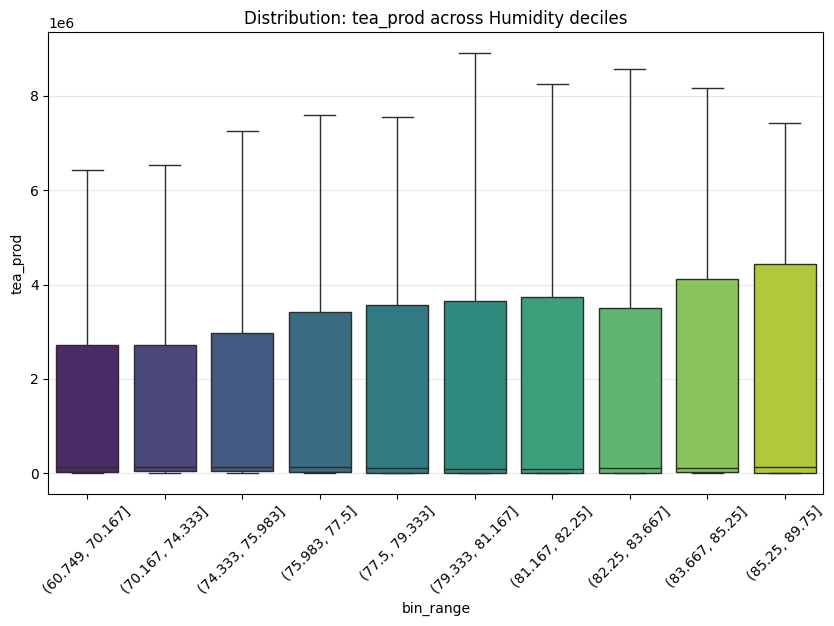

/tmp/ipython-input-200363615.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tmp, x="bin_range", y=y_col, showfliers=False, palette="viridis")


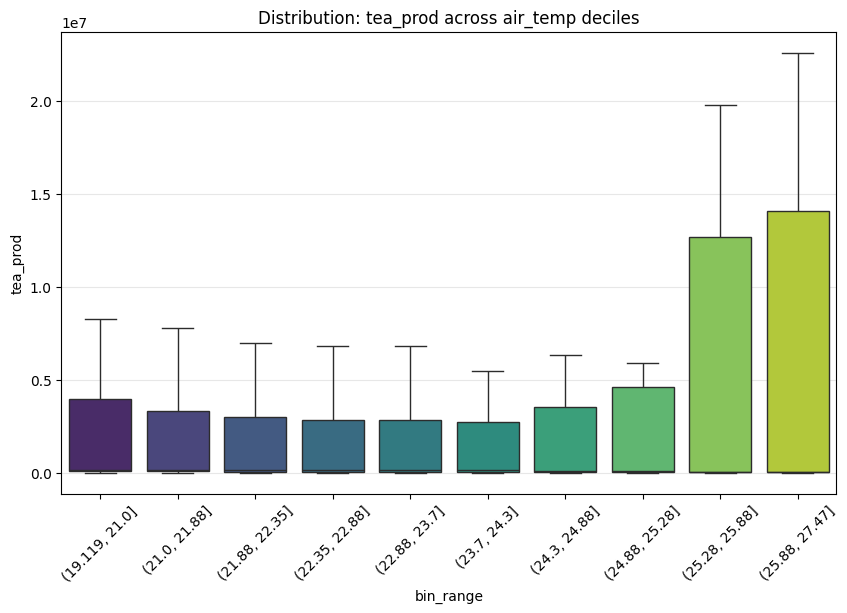

In [ ]:
import seaborn as sns

def binned_boxplot(x_col, y_col="tea_prod", df=None, bins=10):
    tmp = df.copy()

    # Create a new column with the bin ranges
    # precision=0 makes the labels cleaner
    tmp["bin_range"] = pd.qcut(tmp[x_col], q=bins, duplicates="drop")

    plt.figure(figsize=(10, 6))

    # Visualize the distribution within each bin
    sns.boxplot(data=tmp, x="bin_range", y=y_col, showfliers=False, palette="viridis")

    plt.title(f"Distribution: {y_col} across {x_col} deciles")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Usage
for v in ["rainfall", "Humidity", "air_temp"]:
    binned_boxplot(v, df=df)

How to read it

Shows average production at low/medium/high climate levels.

Curves (not straight) indicate nonlinear effects (common in agriculture).

Objective 3: Elevation Effects (Where)
3A) Production differences by elevation (boxplot)

/tmp/ipython-input-843031341.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=elev_order, showfliers=False)


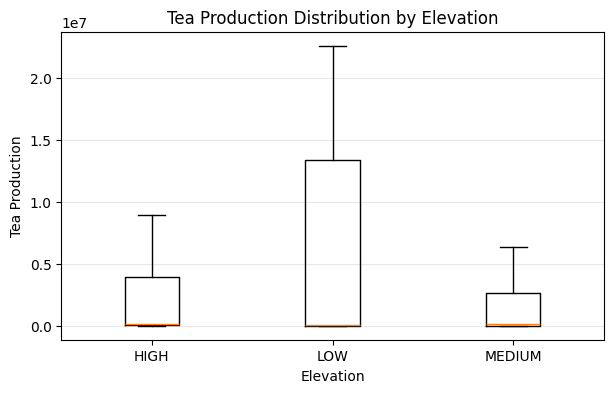

In [ ]:
elev_order = sorted(df["Elevation"].unique())

data = [df.loc[df["Elevation"]==e, "tea_prod"].values for e in elev_order]

plt.figure(figsize=(7,4))
plt.boxplot(data, labels=elev_order, showfliers=False)
plt.title("Tea Production Distribution by Elevation")
plt.xlabel("Elevation")
plt.ylabel("Tea Production")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


How to read it

Higher median line ⇒ typical production is higher at that elevation.

Taller box/whiskers ⇒ more variability (production is less stable).

3B) Seasonality by elevation (monthly averages per elevation)

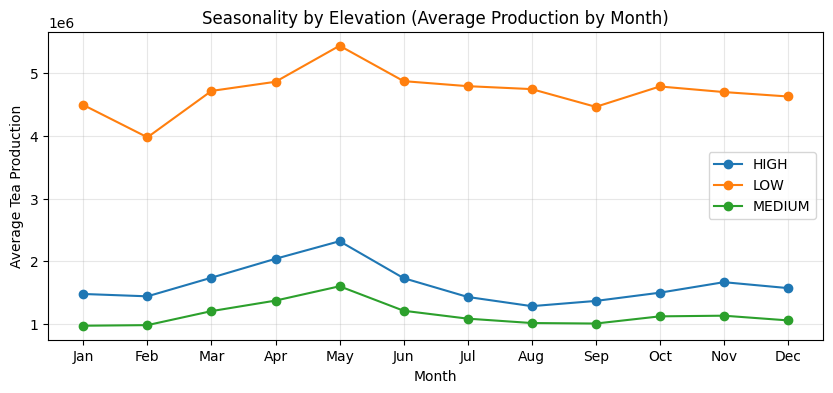

In [ ]:
m_elev = (df.groupby(["Elevation","month_num"])["tea_prod"]
            .mean()
            .reset_index())

plt.figure(figsize=(10,4))
for e in elev_order:
    s = m_elev[m_elev["Elevation"]==e].set_index("month_num")["tea_prod"].reindex(range(1,13))
    plt.plot(s.index, s.values, marker="o", label=e)

plt.xticks(range(1,13), month_names)
plt.title("Seasonality by Elevation (Average Production by Month)")
plt.xlabel("Month")
plt.ylabel("Average Tea Production")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


How to read it

Lines separated ⇒ elevation has a consistent effect.

Lines crossing ⇒ elevation effect depends on season (interaction with time).

3C) Climate–production relationship changes with elevation (small multiples)

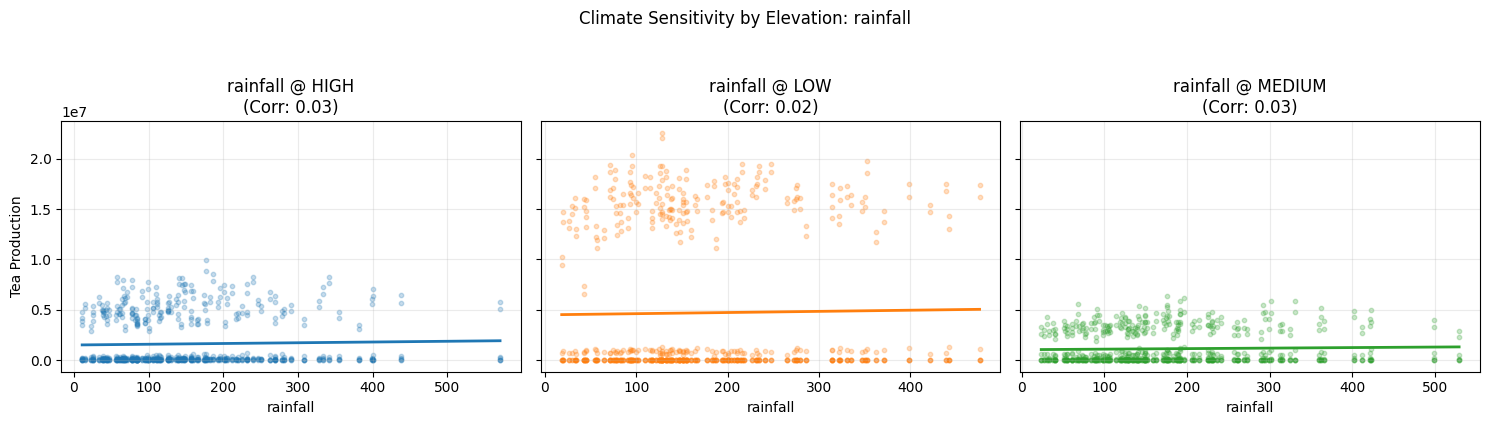

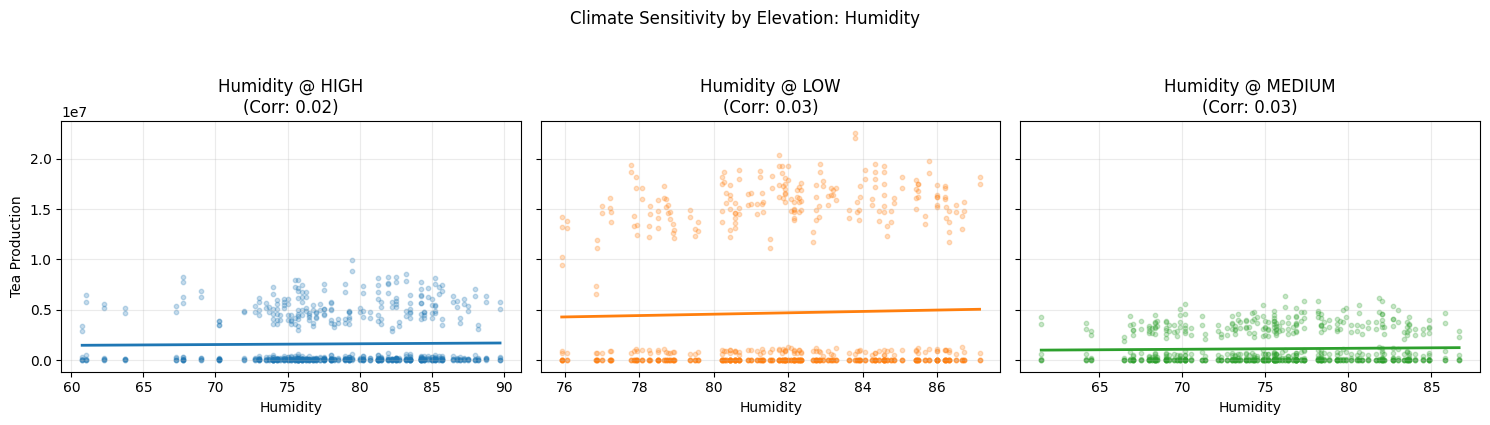

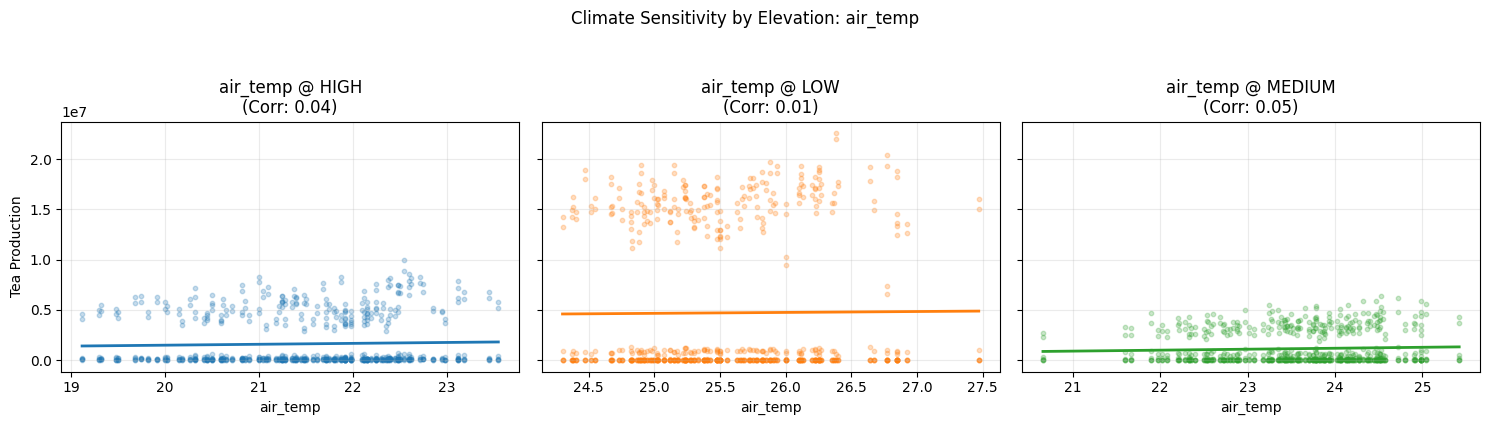

In [ ]:
climate_vars = ["rainfall","Humidity","air_temp"]

elevation_colors = {
    "HIGH": "#1F77B4",
    "LOW": "#FF7F0E",
    "MEDIUM": "#2DA02D"
}

for col in climate_vars:
    fig, axes = plt.subplots(1, len(elev_order), figsize=(15,4), sharey=True)
    for ax, e in zip(axes, elev_order):
        sub = df[df["Elevation"]==e]
        x = sub[col].values
        y = sub["tea_prod"].values

        # Get color for the current elevation
        plot_color = elevation_colors.get(e, "black") # Default to black if elevation not found

        ax.scatter(x, y, s=10, alpha=0.25, color=plot_color)

        # Calculate and plot simple linear trend line
        if len(x) > 1 and len(y) > 1:
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 100)
            ax.plot(xs, m*xs + b, linewidth=2, color=plot_color) # Apply color to trend line

            # Calculate Pearson correlation coefficient
            # Handle cases where there's no variation to avoid NaN correlation
            if np.std(x) != 0 and np.std(y) != 0:
                correlation = np.corrcoef(x, y)[0, 1]
                ax.set_title(f"{col} @ {e}\n(Corr: {correlation:.2f})")
            else:
                ax.set_title(f"{col} @ {e}\n(No Corr: Data too uniform)")
        else:
             ax.set_title(f"{col} @ {e}\n(Not enough data)")

        ax.set_xlabel(col)
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel("Tea Production")
    plt.suptitle(f"Climate Sensitivity by Elevation: {col}", y=1.05)
    plt.tight_layout()
    plt.show()

How to read it

Different slope by elevation ⇒ elevation modifies how climate impacts production.

Example: rainfall might help at LOW elevation but not at HIGH (or vice versa).

Objective 4: Tea Type–Wise Production (Who)
4A) Total production by tea type

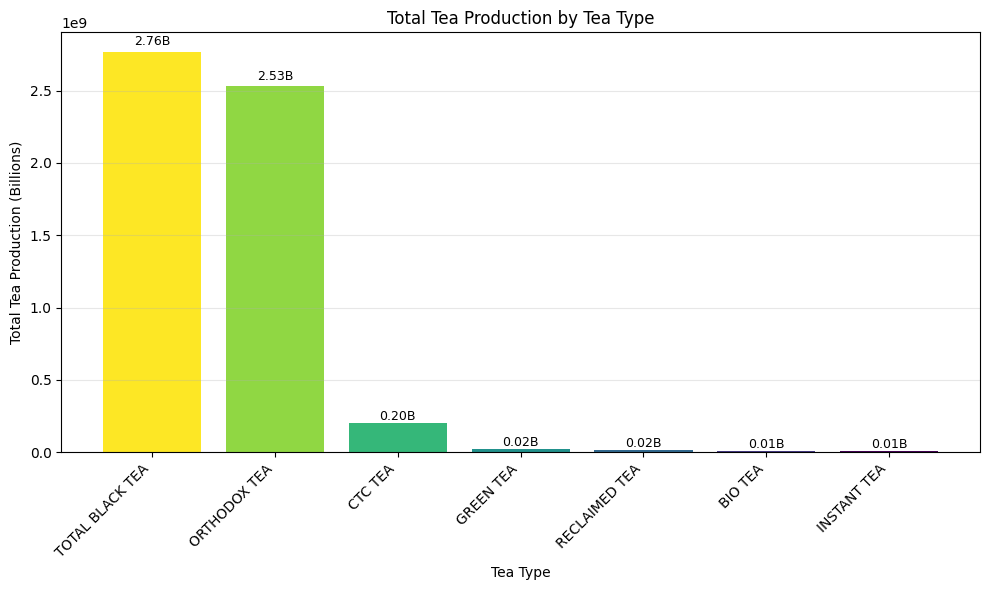

,tea_prod
tea_type,
TOTAL BLACK TEA,2.764769e+09
ORTHODOX TEA,2.530285e+09
CTC TEA,2.004247e+08
GREEN TEA,2.462745e+07
RECLAIMED TEA,1.658759e+07
BIO TEA,1.008660e+07
INSTANT TEA,8.653909e+06


In [ ]:
import numpy as np

type_totals = df.groupby("tea_type")["tea_prod"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

# Get a colormap and generate colors for each bar in reverse order
cmap = plt.colormaps['viridis'](np.linspace(1, 0, len(type_totals)))

bars = plt.bar(type_totals.index, type_totals.values, color=cmap)
plt.title("Total Tea Production by Tea Type")
plt.xlabel("Tea Type")
plt.ylabel("Total Tea Production (Billions)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)

# Add text annotations on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + yval * 0.01, # Position slightly above the bar
             f'{yval/1_000_000_000:.2f}B', # Format in billions with 2 decimal places
             ha='center', va='bottom', fontsize=9)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

type_totals

How to read it

Identifies which tea types contribute most to overall volume.

Helps decide whether to model one global model or separate models per tea type.

4B) Seasonality by tea type (monthly averages per type)

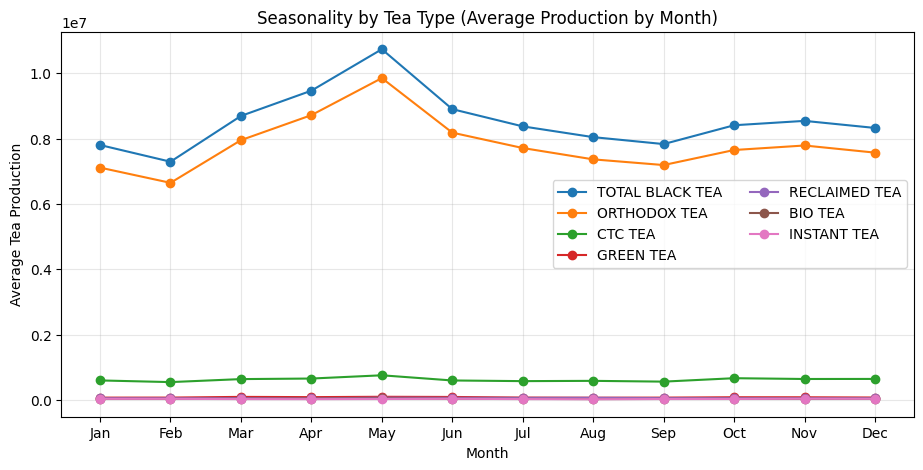

In [ ]:
types = list(type_totals.index)  # in descending order

m_type = (df.groupby(["tea_type","month_num"])["tea_prod"]
            .mean()
            .reset_index())

plt.figure(figsize=(11,5))
for t in types:
    s = m_type[m_type["tea_type"]==t].set_index("month_num")["tea_prod"].reindex(range(1,13))
    plt.plot(s.index, s.values, marker="o", label=t)

plt.xticks(range(1,13), month_names)
plt.title("Seasonality by Tea Type (Average Production by Month)")
plt.xlabel("Month")
plt.ylabel("Average Tea Production")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()


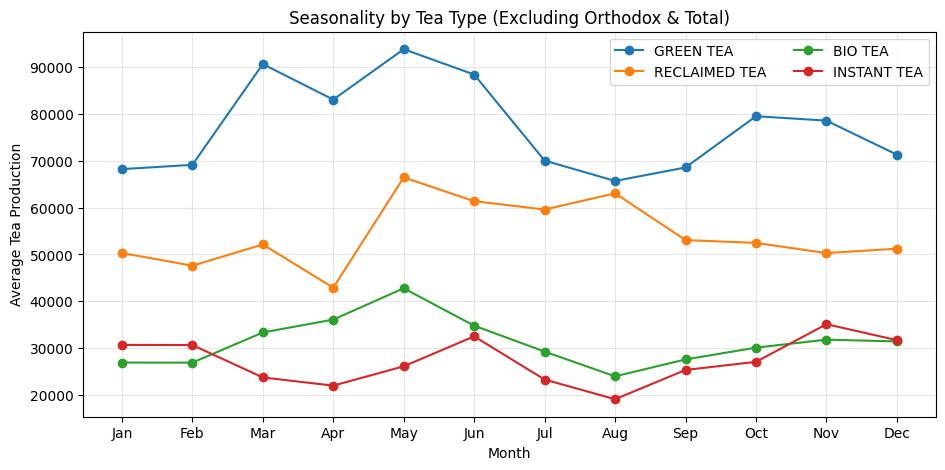

In [ ]:
# 1. Define the types you want to hide
exclude_list = ["ORTHODOX TEA", "TOTAL BLACK TEA","CTC TEA"]

# 2. Filter them out of your types list
# (Assuming 'type_totals' exists from your previous code)
types = [t for t in type_totals.index if t not in exclude_list]

m_type = (df.groupby(["tea_type","month_num"])["tea_prod"]
            .mean()
            .reset_index())

plt.figure(figsize=(11,5))

# 3. Loop through the filtered list only
for t in types:
    s = m_type[m_type["tea_type"]==t].set_index("month_num")["tea_prod"].reindex(range(1,13))
    plt.plot(s.index, s.values, marker="o", label=t)

plt.xticks(range(1,13), month_names)
plt.title("Seasonality by Tea Type (Excluding Orthodox & Total)")
plt.xlabel("Month")
plt.ylabel("Average Tea Production")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

How to read it

Different seasonal shapes ⇒ tea types respond differently to season/time.

If patterns are very different, you often get better accuracy with:

a model that includes tea_type, or

separate models per tea type.

4C) Climate sensitivity by tea type (correlation heatmap per type)

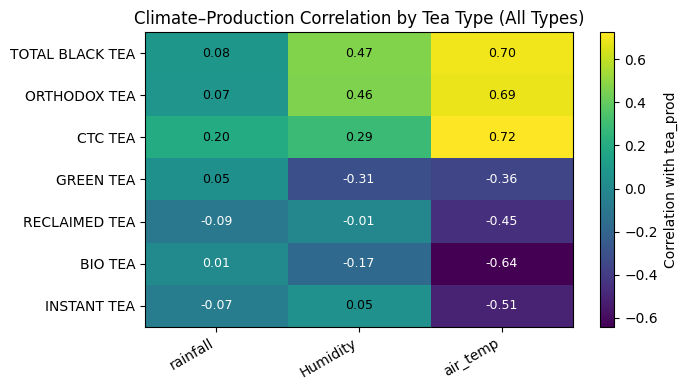

,rainfall,Humidity,air_temp
tea_type,,,
TOTAL BLACK TEA,0.081325,0.465309,0.695515
ORTHODOX TEA,0.073617,0.461916,0.686568
CTC TEA,0.201694,0.287356,0.723960
GREEN TEA,0.047056,-0.306311,-0.355764
RECLAIMED TEA,-0.092077,-0.011209,-0.450177
BIO TEA,0.013669,-0.172892,-0.640106
INSTANT TEA,-0.065101,0.050534,-0.511372


In [ ]:
climate_vars = ["rainfall","Humidity","air_temp"]

rows = []
for t, sub in df.groupby("tea_type"):
    c = sub[["tea_prod"] + climate_vars].corr(numeric_only=True)["tea_prod"][climate_vars]
    rows.append([t] + list(c.values))

corr_by_type = pd.DataFrame(rows, columns=["tea_type"] + climate_vars).set_index("tea_type")
corr_by_type = corr_by_type.loc[type_totals.index]  # Use all tea types from type_totals.index

plt.figure(figsize=(7,4))
im = plt.imshow(corr_by_type.values, aspect="auto", cmap="viridis") # Store the image object
plt.colorbar(im, label="Correlation with tea_prod")
plt.xticks(range(len(climate_vars)), climate_vars, rotation=30, ha="right")
plt.yticks(range(len(corr_by_type.index)), corr_by_type.index)
plt.title("Climate–Production Correlation by Tea Type (All Types)")

# Add text annotations
min_val = corr_by_type.values.min()
max_val = corr_by_type.values.max()
val_range = max_val - min_val

for i in range(corr_by_type.shape[0]): # rows
    for j in range(corr_by_type.shape[1]): # columns
        value = corr_by_type.iloc[i, j]
        if pd.notna(value): # Only add text for non-NaN values
            text_val = f"{value:.2f}" # Format to 2 decimal places

            # Heuristic for text color based on value relative to the range and colormap (viridis)
            # Viridis goes from dark blue/purple (low) to bright yellow (high).
            # Use white text on dark cells, black text on bright cells.
            if val_range > 0:
                normalized_value = (value - min_val) / val_range
            else:
                normalized_value = 0.5 # Default to middle if all values are the same

            color = "white" if normalized_value < 0.5 else "black" # Adjust threshold as needed

            plt.text(j, i, text_val,
                     ha="center", va="center", color=color, fontsize=9)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

corr_by_type

How to read it

Each row is a tea type.

Values show which climate variable matters most for each type (direction + strength).

TEST RMSE: 619,082.052
TEST R^2 : 0.9806


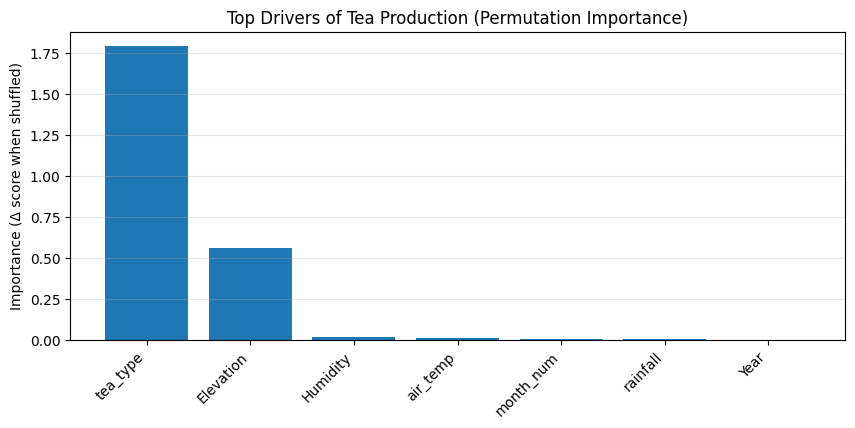

,0
tea_type,1.791741
Elevation,0.561186
Humidity,0.018128
air_temp,0.008134
month_num,0.004026
rainfall,0.001404
Year,0.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Features (time + climate + elevation + tea type)
X = df[["Year","month_num","rainfall","Humidity","air_temp","Elevation","tea_type"]].copy()
y = df["tea_prod"].copy()

# Time-aware split: train up to 2020, test on 2021 (prevents leakage across years)
train_mask = df["Year"] <= 2020
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[~train_mask], y[~train_mask]

cat_features = ["Elevation","tea_type"]
num_features = ["Year","month_num","rainfall","Humidity","air_temp"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
# Calculate RMSE manually to ensure compatibility with all sklearn versions
rmse = mean_squared_error(y_test, pred)**0.5
r2 = r2_score(y_test, pred)

print(f"TEST RMSE: {rmse:,.3f}")
print(f"TEST R^2 : {r2:,.4f}")

# Permutation importance for the original input columns
imp = permutation_importance(pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Use original column names as index (since permutation_importance shuffles input X_test columns)
feat_names = X.columns
imp_mean = pd.Series(imp.importances_mean, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(10,4))
plt.bar(imp_mean.index, imp_mean.values)
plt.title("Top Drivers of Tea Production (Permutation Importance)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance (\u0394 score when shuffled)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

imp_mean